# Structural Intermittency Analysis
**Carbon-Aware Compute Framework**

Covers Phase 3 of the framework. The goal is to identify structural patterns in grid carbon
intensity across five European countries — patterns that are stable enough to act on, not
just transient noise.

All analysis uses `method = 'derived'` from the `carbon_intensity` table, populated in
`carbon_intensity_calculation.ipynb`. GB is excluded throughout — ENTSO-E coverage is
too limited post-Brexit for production-based derived values to be reliable.

## Sections
- **A. Pre-flight checks** — confirm `carbon_intensity` (derived) and `cross_border_flows` are ready
- **B. Hour-of-day profiles** — median carbon intensity by hour across the full year
- **C. Seasonal variation** — repeat B by quarter to assess stability of intraday patterns
- **D. Cross-border flow correlation** — does interconnection actually smooth intermittency?
- **E. Renewable penetration vs carbon intensity** — non-linearity check 
- **F. Findings summary** — key observations and methodology notes for dispatch_framework.ipynb

In [42]:
import os
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv(), override=True)
conn = psycopg2.connect(os.environ["DATABASE_URL"])

def query(sql, params=None):
    return pd.read_sql(sql, conn, params=params)

# Countries included in analysis — GB excluded (see header note)
COUNTRIES = ['DE_LU', 'ES', 'FR', 'IT']

# Colour palette — one per country, consistent across all plots
COUNTRY_COLORS = {
    'DE_LU': '#4878CF',  # blue
    'ES':    '#D65F5F',  # red
    'FR':    '#6ACC65',  # green
    'IT':    '#B47CC7',  # purple
}

print("DB connected ✓")
print(f"Countries in scope: {COUNTRIES}")

DB connected ✓
Countries in scope: ['DE_LU', 'ES', 'FR', 'IT']


---
## Section A — Pre-flight Checks

### A1. Carbon intensity coverage — derived values only

In [2]:
ci_coverage = query("""
    SELECT
        country,
        COUNT(*)                    AS derived_hours,
        MIN(timestamp_utc)::date    AS first_date,
        MAX(timestamp_utc)::date    AS last_date,
        ROUND(MIN(gco2_per_kwh), 1) AS min_gco2,
        ROUND(MAX(gco2_per_kwh), 1) AS max_gco2
    FROM carbon_intensity
    WHERE method = 'derived'
      AND country != 'GB'
    GROUP BY country
    ORDER BY country
""")

if len(ci_coverage) == 0:
    print("⚠️  carbon_intensity table has no derived rows.")
    print("    Run carbon_intensity_calculation.ipynb (Section B) before proceeding.")
else:
    print(ci_coverage.to_string(index=False))
    missing = [c for c in COUNTRIES if c not in ci_coverage['country'].values]
    if missing:
        print(f"\n⚠️  Countries missing from derived data: {missing}")
    else:
        print("\n✓ All four countries present.")

country  derived_hours first_date  last_date  min_gco2  max_gco2
  DE_LU          21403 2023-12-31 2026-06-10      58.1     556.7
     ES          21368 2023-12-31 2026-06-10      41.1     312.2
     FR          21373 2023-12-31 2026-06-10      17.8     103.0
     IT          21403 2023-12-31 2026-06-10      73.9     481.0

✓ All four countries present.


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_77005/1115872673.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


### A2. Cross-border flows coverage

In [3]:
flow_coverage = query("""
    SELECT
        from_country,
        to_country,
        COUNT(*)                    AS rows,
        MIN(timestamp_utc)::date    AS first_date,
        MAX(timestamp_utc)::date    AS last_date
    FROM cross_border_flows
    GROUP BY from_country, to_country
    ORDER BY from_country, to_country
""")

if len(flow_coverage) == 0:
    print("⚠️  cross_border_flows table is empty.")
    print("    Run crossborder_ingest.ipynb before proceeding to Section D.")
    print("    Sections B and C can still run without flow data.")
else:
    print(flow_coverage.to_string(index=False))

from_country to_country  rows first_date  last_date
       DE_LU         FR 21419 2023-12-31 2026-06-11
          ES         FR 21420 2023-12-31 2026-06-11
          FR      DE_LU 21419 2023-12-31 2026-06-11
          FR         ES 21420 2023-12-31 2026-06-11
          FR         GB 21419 2023-12-31 2026-06-11
          FR         IT 21419 2023-12-31 2026-06-11
          GB         FR 21419 2023-12-31 2026-06-11
          IT         FR 21419 2023-12-31 2026-06-11


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_77005/1115872673.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


### A3. Generation table — renewable source types present
Section E requires `wind_onshore`, `wind_offshore`, `solar_pv`, `solar_thermal`, and `hydro`
to be present in the generation table to calculate renewable share.

In [6]:
RENEWABLE_SOURCES = {'wind_onshore', 'wind_offshore', 'solar_pv', 'hydro', 'geothermal'}

source_types = query("""
    SELECT DISTINCT country, source_type
    FROM generation
    WHERE country != 'GB'
    ORDER BY country, source_type
""")

for country, grp in source_types.groupby('country'):
    present    = set(grp['source_type'].values)
    renewables = present & RENEWABLE_SOURCES
    missing    = RENEWABLE_SOURCES - present
    flag = '✓' if not missing else '⚠️ '
    print(f"{flag} {country}: renewable sources present = {sorted(renewables)}")
    if missing:
        print(f"      missing: {sorted(missing)} — Section E renewable share will be partial")

✓ DE_LU: renewable sources present = ['geothermal', 'hydro', 'solar_pv', 'wind_offshore', 'wind_onshore']
✓ ES: renewable sources present = ['geothermal', 'hydro', 'solar_pv', 'wind_offshore', 'wind_onshore']
⚠️  FR: renewable sources present = ['hydro', 'solar_pv', 'wind_offshore', 'wind_onshore']
      missing: ['geothermal'] — Section E renewable share will be partial
✓ IT: renewable sources present = ['geothermal', 'hydro', 'solar_pv', 'wind_offshore', 'wind_onshore']


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_77005/1115872673.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


---
## Section B — Hour-of-Day Carbon Intensity Profiles

For each country, calculate median carbon intensity by hour of day (UTC, 0–23) across
the full dataset. Median rather than mean is used throughout to reduce the influence of
extreme outlier hours (e.g. grid emergencies, data gaps).

This is the primary analytical output of Phase 3. The five-country line chart is the
data source for the Tableau country × hour heatmap.

### B1. Query — median carbon intensity by country × hour

In [43]:
hourly_profile = query("""
    SELECT
        country,
        EXTRACT(HOUR FROM timestamp_utc)                                AS hour_utc,
        ROUND(CAST(
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gco2_per_kwh)
        AS numeric), 1)                                                 AS median_gco2,
        ROUND(AVG(gco2_per_kwh), 1)                                    AS mean_gco2,
        ROUND(CAST(
            PERCENTILE_CONT(0.1) WITHIN GROUP (ORDER BY gco2_per_kwh)
        AS numeric), 1)                                                 AS p10_gco2,
        ROUND(CAST(
            PERCENTILE_CONT(0.9) WITHIN GROUP (ORDER BY gco2_per_kwh)
        AS numeric), 1)                                                 AS p90_gco2,
        COUNT(*)                                                        AS obs
    FROM carbon_intensity
    WHERE method  = 'derived'
      AND country != 'GB'
    GROUP BY country, hour_utc
    ORDER BY country, hour_utc
""")

print(hourly_profile.to_string(index=False))

hourly_profile.to_csv('../data/heatmap_data.csv', index=False)

country  hour_utc  median_gco2  mean_gco2  p10_gco2  p90_gco2  obs
  DE_LU       0.0        339.0      327.1     157.2     462.4  892
  DE_LU       1.0        336.3      325.6     158.0     458.5  891
  DE_LU       2.0        336.9      325.9     155.9     459.3  892
  DE_LU       3.0        340.5      327.9     156.7     463.3  892
  DE_LU       4.0        344.8      332.6     165.7     469.3  892
  DE_LU       5.0        346.6      334.7     168.7     471.4  892
  DE_LU       6.0        339.9      330.1     162.3     471.8  892
  DE_LU       7.0        328.9      318.9     139.6     473.2  892
  DE_LU       8.0        323.4      305.8     115.3     471.1  892
  DE_LU       9.0        318.7      295.4      96.2     470.0  892
  DE_LU      10.0        316.8      289.8      89.0     464.6  892
  DE_LU      11.0        316.5      287.7      85.9     459.4  892
  DE_LU      12.0        319.1      288.1      86.2     458.7  892
  DE_LU      13.0        322.7      291.1      86.9     458.2 

/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_77005/1115872673.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


### B2. Sanity checks — expected intraday patterns
Verify that the output matches known physical expectations before proceeding to visualisation.

In [8]:
checks_passed = True

for country, grp in hourly_profile.groupby('country'):
    grp = grp.set_index('hour_utc')

    if country == 'FR':
        # France: nuclear baseload — range should be narrow (< 40 gCO2/kWh peak-to-trough)
        spread = grp['median_gco2'].max() - grp['median_gco2'].min()
        flag = '✓' if spread < 40 else '⚠️ '
        print(f"{flag} FR intraday spread: {spread:.1f} gCO2/kWh (expected < 40)")
        if spread >= 40:
            checks_passed = False

    if country == 'ES':
        # Spain: solar — minimum should fall between hours 10–15 UTC
        min_hour = int(grp['median_gco2'].idxmin())
        flag = '✓' if 9 <= min_hour <= 15 else '⚠️ '
        print(f"{flag} ES daily minimum at hour {min_hour} UTC (expected 09–15)")
        if not (9 <= min_hour <= 15):
            checks_passed = False

    if country == 'DE_LU':
        # Germany: gas peaking in evening — maximum should fall between hours 16–21 UTC
        max_hour = int(grp['median_gco2'].idxmax())
        flag = '✓' if 15 <= max_hour <= 21 else '⚠️ '
        print(f"{flag} DE_LU daily maximum at hour {max_hour} UTC (expected 15–21)")
        if not (15 <= max_hour <= 21):
            checks_passed = False

    if country == 'IT':
        # Italy: gas-heavy, median should exceed 250 gCO2/kWh at peak
        peak = grp['median_gco2'].max()
        flag = '✓' if peak > 250 else '⚠️ '
        print(f"{flag} IT peak median: {peak:.1f} gCO2/kWh (expected > 250)")
        if peak <= 250:
            checks_passed = False

print()
if checks_passed:
    print("✓ All sanity checks passed — intraday patterns consistent with generation profiles.")
else:
    print("⚠️  One or more checks failed — review carbon_intensity derivation before proceeding.")

✓ DE_LU daily maximum at hour 19 UTC (expected 15–21)
✓ ES daily minimum at hour 12 UTC (expected 09–15)
✓ FR intraday spread: 5.4 gCO2/kWh (expected < 40)
✓ IT peak median: 402.8 gCO2/kWh (expected > 250)

✓ All sanity checks passed — intraday patterns consistent with generation profiles.


### B3. Visualisation — full-year median profiles
Five-country line chart with P10–P90 band for Germany (highest variance country) as a
variability reference. This is the primary sanity check visual — if the profiles look
physically plausible, upstream derivation is sound.

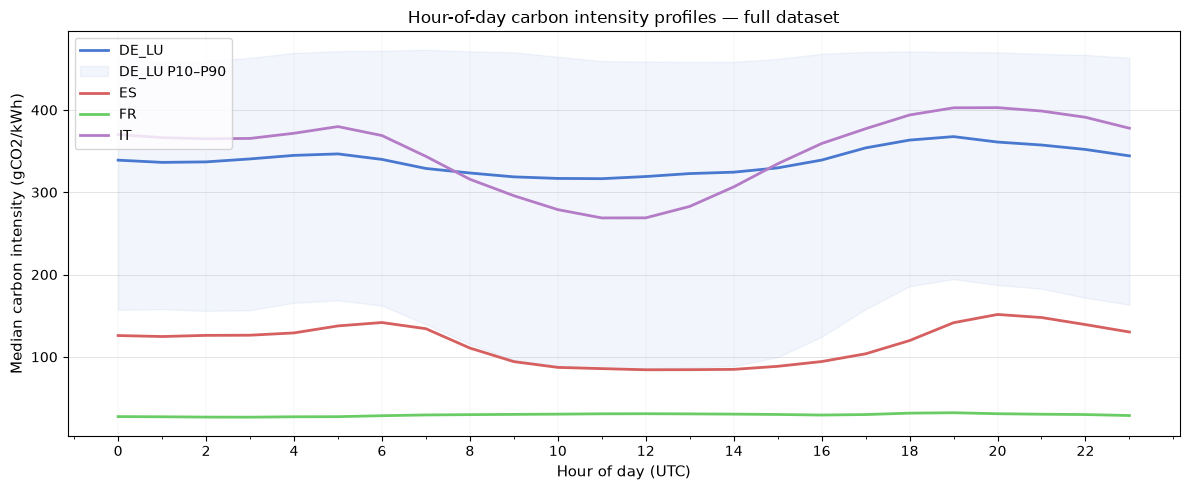


Expected patterns:
  FR — near-flat low line (nuclear baseload)
  ES — V-shaped trough peaking around hours 11–14 UTC (solar)
  DE_LU — elevated with evening peak hours 16–20 UTC (gas backup)
  IT — elevated flat, modest solar dip midday


In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

for country, grp in hourly_profile.groupby('country'):
    grp = grp.sort_values('hour_utc')
    ax.plot(
        grp['hour_utc'], grp['median_gco2'],
        label=country,
        color=COUNTRY_COLORS[country],
        linewidth=2,
    )
    # P10–P90 shaded band for DE_LU only (most variable; avoids visual clutter)
    if country == 'DE_LU':
        ax.fill_between(
            grp['hour_utc'], grp['p10_gco2'], grp['p90_gco2'],
            color=COUNTRY_COLORS[country], alpha=0.07,
            label='DE_LU P10–P90'
        )

ax.set_xlabel('Hour of day (UTC)', fontsize=11)
ax.set_ylabel('Median carbon intensity (gCO2/kWh)', fontsize=11)
ax.set_title('Hour-of-day carbon intensity profiles — full dataset', fontsize=12)
ax.set_xticks(range(0, 24, 2))
ax.xaxis.set_minor_locator(mticker.MultipleLocator(1))
ax.legend(loc='upper left', fontsize=10)
ax.grid(axis='y', linewidth=0.4, alpha=0.6)
ax.grid(axis='x', linewidth=0.2, alpha=0.4)

plt.tight_layout()
plt.show()

print()
print("Expected patterns:")
print("  FR — near-flat low line (nuclear baseload)")
print("  ES — V-shaped trough peaking around hours 11–14 UTC (solar)")
print("  DE_LU — elevated with evening peak hours 16–20 UTC (gas backup)")
print("  IT — elevated flat, modest solar dip midday")

---
## Section C — Seasonal Variation

Repeat the hour-of-day profile split by quarter (Q1–Q4). This determines whether the
intraday patterns in Section B are stable year-round or season-dependent — which directly
affects how robust any dispatch recommendation will be.

Key expectations:
- Germany: wind-heavy in Q1 (winter) → lower overnight carbon, more volatile intraday
- Spain: solar peaks are Q2–Q3 (summer) → midday trough deeper in summer than winter
- France: nuclear output relatively stable across seasons — minimal seasonal effect

### C1. Query — median carbon intensity by country × quarter × hour

In [44]:
seasonal_profile = query("""
    SELECT
        country,
        EXTRACT(QUARTER FROM timestamp_utc)                             AS quarter,
        EXTRACT(HOUR FROM timestamp_utc)                               AS hour_utc,
        ROUND(CAST(
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gco2_per_kwh)
        AS numeric), 1)                                                 AS median_gco2,
        COUNT(*)                                                        AS obs
    FROM carbon_intensity
    WHERE method  = 'derived'
      AND country != 'GB'
    GROUP BY country, quarter, hour_utc
    ORDER BY country, quarter, hour_utc
""")

# Observation counts per quarter — confirm sufficient data in each cell
obs_check = seasonal_profile.groupby(['country', 'quarter'])['obs'].agg(['min', 'max'])
print("Observations per country × quarter:")
print(obs_check)
print()
print("Minimum expected: ~60 obs per cell (1 year ÷ 4 quarters ÷ 24 hours ≈ 91 days × 1 hour).")
print("Low counts may reflect partial quarters at dataset edges — acceptable if > 30.")

seasonal_profile.to_csv('../data/seasonal_data.csv', index=False)

Observations per country × quarter:
                 min  max
country quarter          
DE_LU   1.0      268  271
        2.0      252  253
        3.0      184  184
        4.0      184  186
ES      1.0      268  271
        2.0      250  252
        3.0      184  184
        4.0      184  186
FR      1.0      267  270
        2.0      252  253
        3.0      184  184
        4.0      183  186
IT      1.0      268  271
        2.0      252  253
        3.0      184  184
        4.0      184  186

Minimum expected: ~60 obs per cell (1 year ÷ 4 quarters ÷ 24 hours ≈ 91 days × 1 hour).
Low counts may reflect partial quarters at dataset edges — acceptable if > 30.


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_77005/1115872673.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


### C2. Seasonal spread — how much does the intraday trough change across quarters?
For each country, calculate the peak-to-trough range per quarter. A large Q1–Q4 spread
signals that a single annual dispatch ranking may not hold year-round.

In [ ]:
seasonal_spread = query("""
    WITH quarterly_medians AS (
        SELECT
            country,
            EXTRACT(QUARTER FROM timestamp_utc)                         AS quarter,
            ROUND(CAST(
                PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gco2_per_kwh)
            AS numeric), 1)                                             AS quarterly_median
        FROM carbon_intensity
        WHERE method  = 'derived'
          AND country != 'GB'
        GROUP BY country, quarter
    )
    SELECT
        country,
        quarter,
        quarterly_median,
        MIN(quarterly_median) OVER (PARTITION BY country)              AS best_quarter_median,
        MAX(quarterly_median) OVER (PARTITION BY country)              AS worst_quarter_median,
        MAX(quarterly_median) OVER (PARTITION BY country)
            - MIN(quarterly_median) OVER (PARTITION BY country)        AS seasonal_range
    FROM quarterly_medians
    ORDER BY country, quarter
""")

print(seasonal_spread.to_string(index=False))



country  quarter  quarterly_median  best_quarter_median  worst_quarter_median  seasonal_range
  DE_LU      1.0             364.9                296.3                 364.9            68.6
  DE_LU      2.0             336.1                296.3                 364.9            68.6
  DE_LU      3.0             296.3                296.3                 364.9            68.6
  DE_LU      4.0             342.3                296.3                 364.9            68.6
     ES      1.0              96.5                 96.5                 138.3            41.8
     ES      2.0             107.8                 96.5                 138.3            41.8
     ES      3.0             119.8                 96.5                 138.3            41.8
     ES      4.0             138.3                 96.5                 138.3            41.8
     FR      1.0              38.5                 24.8                  38.5            13.7
     FR      2.0              24.8                 24.8     

/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_77005/1115872673.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


### C3. Visualisation — seasonal subplots per country
One row per country, one line per quarter. Intended as a quick visual check —
full seasonal analysis moves to Tableau (Step 24 parameter toggle).

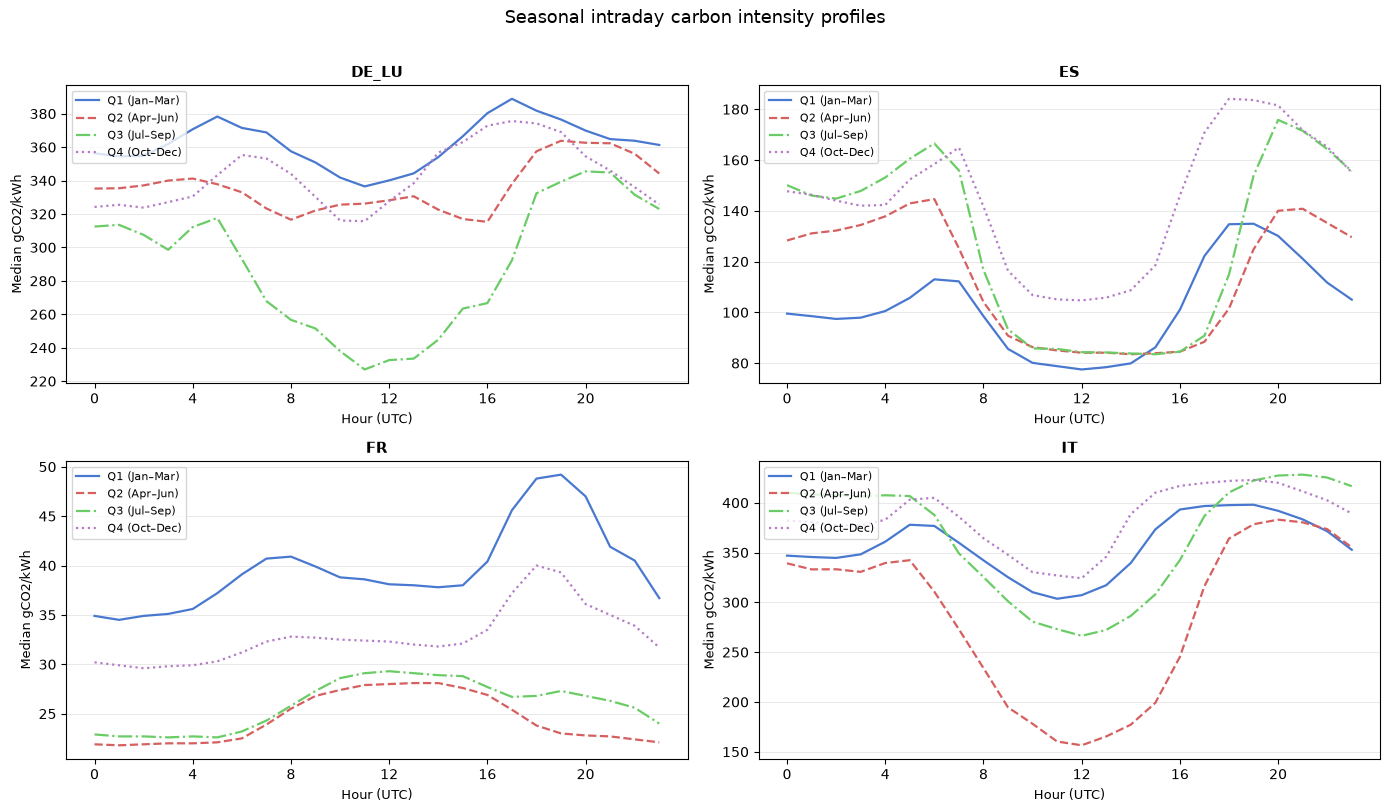

In [16]:
QUARTER_STYLES = {
    1: ('Q1 (Jan–Mar)', '#4878CF', '-'),
    2: ('Q2 (Apr–Jun)', '#D65F5F', '--'),
    3: ('Q3 (Jul–Sep)', '#6ACC65', '-.'),
    4: ('Q4 (Oct–Dec)', '#B47CC7', ':'),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)
axes_flat = axes.flatten()

for ax, country in zip(axes_flat, COUNTRIES):
    cdf = seasonal_profile[seasonal_profile['country'] == country]
    for q, (label, color, ls) in QUARTER_STYLES.items():
        qdf = cdf[cdf['quarter'] == q].sort_values('hour_utc')
        if len(qdf) == 0:
            continue
        ax.plot(qdf['hour_utc'], qdf['median_gco2'],
                label=label, color=color, linestyle=ls, linewidth=1.6)

    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.set_xlabel('Hour (UTC)', fontsize=9)
    ax.set_ylabel('Median gCO2/kWh', fontsize=9)
    ax.set_xticks(range(0, 24, 4))
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(axis='y', linewidth=0.4, alpha=0.5)

plt.suptitle('Seasonal intraday carbon intensity profiles', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### C4. Stability flag — countries where seasonal variation materially changes the intraday ranking
If the hour that minimises carbon intensity shifts by more than 3 hours between the best
and worst quarter, the dispatch recommendation needs a seasonal qualifier.

In [40]:
print(f"{'Country':<8} {'Q1':>6} {'Q2':>6} {'Q3':>6} {'Q4':>6} {'Shift':>8}  {'Flag'}")
print("-" * 75)

for country, cdf in seasonal_profile.groupby('country'):
    trough_info = {}
    for q, qdf in cdf.groupby('quarter'):
        qdf = qdf.sort_values('hour_utc')
        min_idx = qdf['median_gco2'].idxmin()
        trough_info[int(q)] = {
            'hour':   int(qdf.loc[min_idx, 'hour_utc']),
            'median': float(qdf.loc[min_idx, 'median_gco2']),
        }

    all_hours = [v['hour'] for v in trough_info.values()]
    shift     = max(all_hours) - min(all_hours)
    flag      = '⚠️  seasonal qualifier needed' if shift > 3 else '✓ stable'

    q_str = ''.join(
        f"  h{trough_info[q]['hour']:02d}" for q in [1, 2, 3, 4]
    )
    print(f"{country:<8}{q_str}   {shift:>5}h    {flag}")

Country      Q1     Q2     Q3     Q4    Shift  Flag
---------------------------------------------------------------------------
DE_LU     h11  h16  h11  h11       5h    ⚠️  seasonal qualifier needed
ES        h12  h14  h15  h12       3h    ✓ stable
FR        h01  h01  h03  h02       2h    ✓ stable
IT        h11  h12  h12  h12       1h    ✓ stable


---
## Section D — Cross-Border Flow Correlation

For each major interconnector, calculate the Pearson correlation between:
- The **exporting country's renewable surplus** (wind + solar generation as % of total)
- The **import volume** on that interconnector

A positive correlation means exports are driven by renewable generation surpluses —
i.e. interconnection is actively smoothing intermittency. A near-zero or negative
correlation suggests trade is driven by price arbitrage or demand differences instead.

Interconnectors in scope (from `cross_border_flows` table):
- FR → DE_LU (nuclear export route)
- FR → ES
- FR → GB (IFA)
- DE_LU → IT
- ES → IT

### D1. Renewable surplus calculation
Renewable surplus = (wind_onshore + wind_offshore + solar_pv + solar_thermal + hydro) / total_mw

In [23]:
renewable_share = query("""
    SELECT
        country,
        timestamp_utc,
        ROUND(
            100.0 * SUM(CASE WHEN source_type IN
                ('wind_onshore', 'wind_offshore', 'solar_pv', 'hydro', 'geothermal')
                THEN GREATEST(mw, 0) ELSE 0 END)
            / NULLIF(SUM(GREATEST(mw, 0)), 0)
        , 2)                                                            AS renewable_pct
    FROM generation
    WHERE country != 'GB'
      AND mw IS NOT NULL
    GROUP BY country, timestamp_utc
    HAVING SUM(GREATEST(mw, 0)) > 0
    ORDER BY country, timestamp_utc
""")

print("Renewable share summary by country:")
print(
    renewable_share.groupby('country')['renewable_pct']
    .describe(percentiles=[0.1, 0.5, 0.9])
    .round(1)
)

/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_77005/1115872673.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


Renewable share summary by country:
           count  mean   std   min   10%   50%   90%   max
country                                                   
DE_LU    21403.0  33.8  24.8   0.4   6.3  26.4  75.2  90.3
ES       21368.0  54.3  14.2  12.0  34.3  56.5  70.8  81.8
FR       21373.0  17.8   8.3   0.7   7.9  16.6  29.6  46.4
IT       21403.0  31.2  20.2   1.3   9.8  25.8  61.4  90.8


### D2. Correlation — exporting country renewable surplus vs import volume

In [26]:
# Interconnectors to test: (exporting_country, importing_country)
INTERCONNECTORS = [
    ('FR',    'DE_LU'),
    ('DE_LU', 'FR'),
    ('FR',    'ES'),
    ('ES',    'FR'),
    ('FR',    'IT'),
    ('IT',    'FR'),
    ('FR',    'GB'),   # GB renewable_pct unreliable — note in output
    ('GB',    'FR'),   # GB renewable_pct unreliable — note in output
]

correlation_results = []

for exporter, importer in INTERCONNECTORS:
    corr_df = query("""
        SELECT
            ROUND(CAST(
                CORR(rs.renewable_pct, cbf.mw)
            AS numeric), 4)             AS pearson_r,
            COUNT(*)                    AS matched_hours,
            ROUND(AVG(cbf.mw), 1)       AS avg_flow_mw,
            ROUND(AVG(rs.renewable_pct), 1) AS avg_renewable_pct
        FROM (
            SELECT
                timestamp_utc,
                ROUND(
                    100.0 * SUM(CASE WHEN source_type IN
                        ('wind_onshore', 'wind_offshore', 'solar_pv','hydro', 'geothermal')
                        THEN GREATEST(mw, 0) ELSE 0 END)
                    / NULLIF(SUM(GREATEST(mw, 0)), 0)
                , 2) AS renewable_pct
            FROM generation
            WHERE country = %(exporter)s
              AND mw IS NOT NULL
            GROUP BY timestamp_utc
            HAVING SUM(GREATEST(mw, 0)) > 0
        ) rs
        JOIN cross_border_flows cbf
            ON  cbf.from_country  = %(exporter)s
            AND cbf.to_country    = %(importer)s
            AND cbf.timestamp_utc = rs.timestamp_utc
        WHERE cbf.mw IS NOT NULL
    """, params={'exporter': exporter, 'importer': importer})

    if len(corr_df) == 0 or corr_df['pearson_r'].isna().all():
        correlation_results.append({
            'interconnector': f"{exporter}→{importer}",
            'pearson_r': None,
            'matched_hours': 0,
            'avg_flow_mw': None,
            'avg_renewable_pct': None,
            'interpretation': 'No data'
        })
        continue

    r = float(corr_df['pearson_r'].iloc[0])

    if r is None or np.isnan(r):
        interp = 'No data'
    elif r >= 0.3:
        interp = 'Renewable-driven exports'
    elif r >= 0.1:
        interp = 'Weak renewable signal'
    elif r >= -0.1:
        interp = 'No clear relationship'
    else:
        interp = 'Demand/price arbitrage dominant'

    correlation_results.append({
        'interconnector': f"{exporter}→{importer}",
        'pearson_r': round(r, 4),
        'matched_hours': int(corr_df['matched_hours'].iloc[0]),
        'avg_flow_mw': float(corr_df['avg_flow_mw'].iloc[0]),
        'avg_renewable_pct': float(corr_df['avg_renewable_pct'].iloc[0]),
        'interpretation': interp,
    })

corr_table = pd.DataFrame(correlation_results)
print(corr_table.to_string(index=False))

/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_77005/1115872673.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


interconnector  pearson_r  matched_hours  avg_flow_mw  avg_renewable_pct                  interpretation
      FR→DE_LU    -0.1660          21373       2332.3               17.8 Demand/price arbitrage dominant
      DE_LU→FR     0.0161          21403         74.1               33.8           No clear relationship
         FR→ES    -0.0659          21373        912.6               17.8           No clear relationship
         ES→FR     0.4203          21368        795.4               54.3        Renewable-driven exports
         FR→IT    -0.1878          21373       2422.3               17.8 Demand/price arbitrage dominant
         IT→FR     0.0507          21403          6.9               31.2           No clear relationship
         FR→GB     0.1614          21371       2566.5               17.8           Weak renewable signal
         GB→FR     0.0180          20010         77.7               94.8           No clear relationship


### D3. Net flow position — which countries are structural exporters vs importers?
Positive net_mw = country is a net exporter on average over the dataset period.

In [45]:
net_position = query("""
    WITH forward AS (
        SELECT from_country AS country, timestamp_utc,  mw AS export_mw
        FROM cross_border_flows
    ),
    reverse AS (
        SELECT to_country   AS country, timestamp_utc,  mw AS import_mw
        FROM cross_border_flows
    )
    SELECT
        COALESCE(f.country, r.country)                          AS country,
        ROUND(SUM(COALESCE(f.export_mw, 0))::numeric / 1000, 1) AS total_export_gwh,
        ROUND(SUM(COALESCE(r.import_mw, 0))::numeric / 1000, 1) AS total_import_gwh,
        ROUND(
            (SUM(COALESCE(f.export_mw, 0)) - SUM(COALESCE(r.import_mw, 0)))::numeric
            / 1000
        , 1)                                                    AS net_position_gwh
    FROM forward f
    FULL OUTER JOIN reverse r
        ON  r.country       = f.country
        AND r.timestamp_utc = f.timestamp_utc
    GROUP BY COALESCE(f.country, r.country)
    ORDER BY net_position_gwh DESC
""")

# annualized (data range: 2024-01-01 to 2026-06-10)
date_range = query("""
    SELECT MIN(timestamp_utc)::date AS start_date,
           MAX(timestamp_utc)::date AS end_date
    FROM cross_border_flows
""")
start = date_range['start_date'].iloc[0]
end   = date_range['end_date'].iloc[0]

DATASET_YEARS = 21403 / 8760

net_position['annual_net_gwh'] = (net_position['net_position_gwh'] / DATASET_YEARS).round(1)

print(f"Coverage: {start} to {end}")
print(f"Annualised net position (divided by {DATASET_YEARS:.2f} years):")
print()
print("Net flow position across all study interconnectors (positive = net exporter):")
print(net_position[['country', 'total_export_gwh', 'total_import_gwh',
                     'net_position_gwh', 'annual_net_gwh']].to_string(index=False))
print()
print("Note: totals reflect only the interconnectors ingested in cross_border_flows.")
print("France's net export position is the most complete figure in this dataset,")
print("covering its four primary export corridors (FR↔DE_LU, FR↔ES, FR↔IT, FR↔GB).")
print("DE_LU, IT, and GB net positions are materially understated — each has significant")
print("interconnections outside the study perimeter:")
print("  DE_LU: NL, PL, CZ, DK not ingested")
print("  IT:    CH, AT, SI not ingested (largest physical interconnections for Italy)")
print("  GB:    BE, NO not ingested; post-Brexit ENTSO-E coverage also limits reliability")
print("ES net position is closest to true — ES↔FR covers the primary interconnection.")

net_position.to_csv('../data/net_position_data.csv', index=False)

Coverage: 2023-12-31 to 2026-06-11
Annualised net position (divided by 2.44 years):

Net flow position across all study interconnectors (positive = net exporter):
country  total_export_gwh  total_import_gwh  net_position_gwh  annual_net_gwh
     FR          705203.1           81251.2          623951.9        255376.3
     ES           16997.2           19585.9           -2588.8         -1059.6
  DE_LU            1585.4           49909.1          -48323.7        -19778.3
     IT             148.0           51861.6          -51713.7        -21165.8
     GB            1582.2           54944.2          -53361.9        -21840.4

Note: totals reflect only the interconnectors ingested in cross_border_flows.
France's net export position is the most complete figure in this dataset,
covering its four primary export corridors (FR↔DE_LU, FR↔ES, FR↔IT, FR↔GB).
DE_LU, IT, and GB net positions are materially understated — each has significant
interconnections outside the study perimeter:
  DE_LU: NL,

/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_77005/1115872673.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


---
## Section E — Renewable Penetration vs Carbon Intensity


For each country × hour observation, plot renewable share against carbon intensity.
The relationship is non-linear: a country at 60% renewable penetration is not
60% cleaner than one at 0%. Residual fossil dispatchable generation and nuclear
floor effects create a curve that flattens at high renewable share.

This analysis also flags France as an outlier: very low carbon intensity at low renewable
share — driven by nuclear rather than renewables.

### E1. Query — hourly renewable share and carbon intensity

In [46]:
scatter_data = query("""
    SELECT
        ci.country,
        ci.timestamp_utc,
        ci.gco2_per_kwh,
        ROUND(
            100.0 * SUM(CASE WHEN g.source_type IN
                ('wind_onshore', 'wind_offshore', 'solar_pv', 'geothermal', 'hydro')
                THEN GREATEST(g.mw, 0) ELSE 0 END)
            / NULLIF(SUM(GREATEST(g.mw, 0)), 0)
        , 2)                                                        AS renewable_pct
    FROM carbon_intensity ci
    JOIN generation g
        ON  g.country       = ci.country
        AND g.timestamp_utc = ci.timestamp_utc
    WHERE ci.method  = 'derived'
      AND ci.country != 'GB'
      AND g.mw IS NOT NULL
    GROUP BY ci.country, ci.timestamp_utc, ci.gco2_per_kwh
    HAVING SUM(GREATEST(g.mw, 0)) > 0
    ORDER BY ci.country, ci.timestamp_utc
""")

print(f"Loaded {len(scatter_data):,} country × hour observations.")

scatter_data.to_csv('../data/renewable_pct_ci_data.csv', index=False)

/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_77005/1115872673.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


Loaded 85,547 country × hour observations.


### E2. Visualisation — renewable share vs carbon intensity scatter

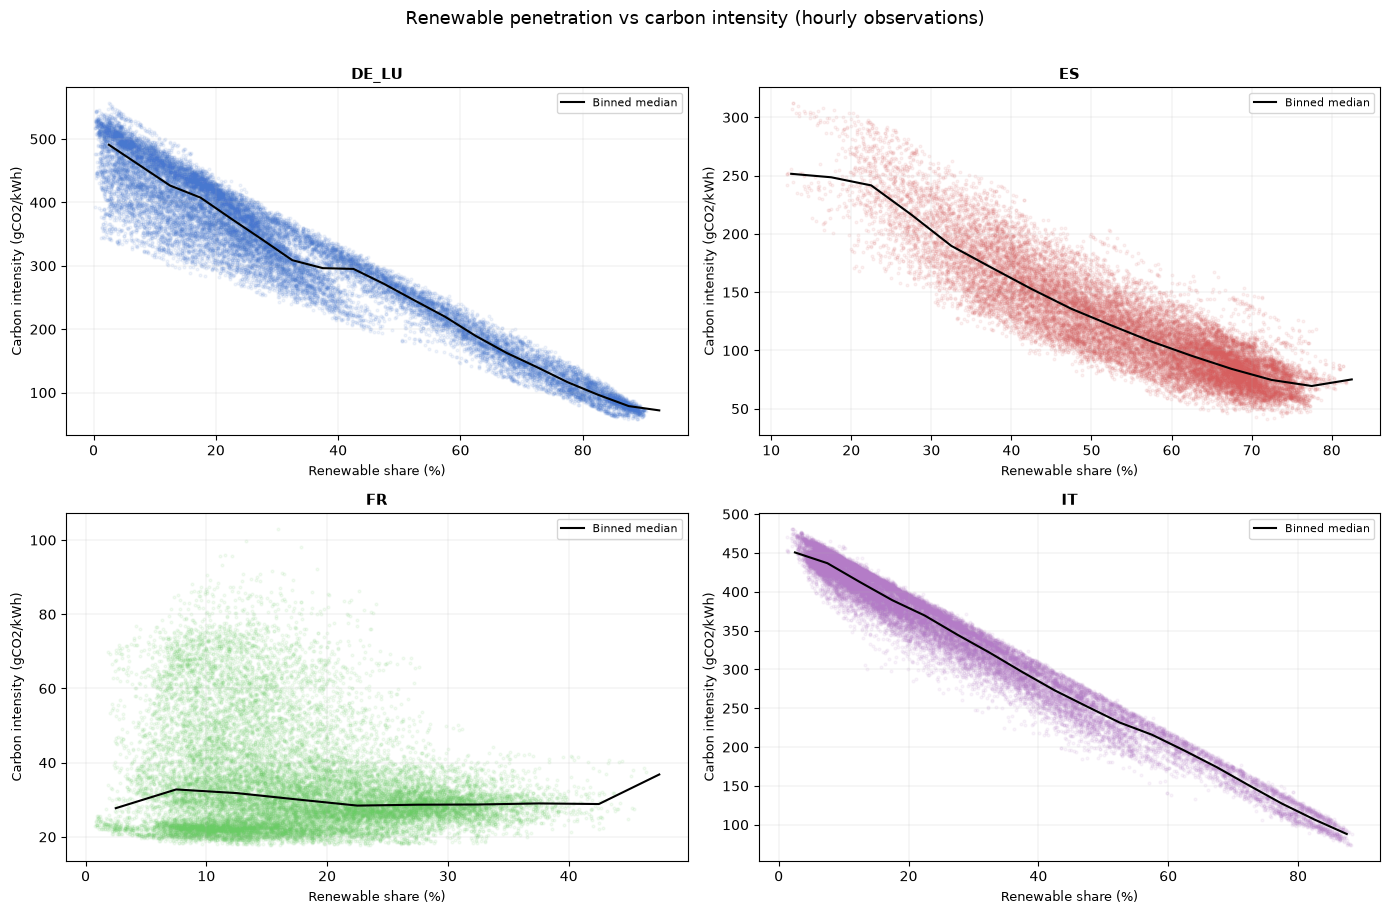

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=False)
axes_flat = axes.flatten()

for ax, country in zip(axes_flat, COUNTRIES):
    cdf = scatter_data[scatter_data['country'] == country]
    ax.scatter(
        cdf['renewable_pct'], cdf['gco2_per_kwh'],
        alpha=0.08, s=4, color=COUNTRY_COLORS[country]
    )

    # Binned median trend line
    bins = np.arange(0, 105, 5)
    cdf = cdf.copy()
    cdf['bin'] = pd.cut(cdf['renewable_pct'], bins=bins, labels=bins[:-1] + 2.5)
    trend = cdf.groupby('bin', observed=True)['gco2_per_kwh'].median().reset_index()
    trend['bin'] = trend['bin'].astype(float)
    ax.plot(trend['bin'], trend['gco2_per_kwh'],
            color='black', linewidth=1.5, label='Binned median')

    ax.set_title(country, fontsize=11, fontweight='bold')
    ax.set_xlabel('Renewable share (%)', fontsize=9)
    ax.set_ylabel('Carbon intensity (gCO2/kWh)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(linewidth=0.3, alpha=0.5)

plt.suptitle('Renewable penetration vs carbon intensity (hourly observations)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### E3. Non-linearity quantification — carbon intensity at 20%, 50%, 80% renewable share

In [36]:
nonlinearity = query("""
    WITH binned AS (
        SELECT
            ci.country,
            ci.gco2_per_kwh,
            ROUND(
                100.0 * SUM(CASE WHEN g.source_type IN
                    ('wind_onshore', 'wind_offshore', 'solar_pv', 'solar_thermal', 'hydro')
                    THEN GREATEST(g.mw, 0) ELSE 0 END)
                / NULLIF(SUM(GREATEST(g.mw, 0)), 0)
            , 0)                                                    AS renewable_pct
        FROM carbon_intensity ci
        JOIN generation g
            ON  g.country       = ci.country
            AND g.timestamp_utc = ci.timestamp_utc
        WHERE ci.method  = 'derived'
          AND ci.country != 'GB'
          AND g.mw IS NOT NULL
        GROUP BY ci.country, ci.timestamp_utc, ci.gco2_per_kwh
        HAVING SUM(GREATEST(g.mw, 0)) > 0
    )
    SELECT
        country,
        ROUND(CAST(
            PERCENTILE_CONT(0.5) WITHIN GROUP
            (ORDER BY gco2_per_kwh) FILTER (WHERE renewable_pct BETWEEN 15 AND 25)
        AS numeric), 1)                                             AS median_gco2_at_20pct,
        ROUND(CAST(
            PERCENTILE_CONT(0.5) WITHIN GROUP
            (ORDER BY gco2_per_kwh) FILTER (WHERE renewable_pct BETWEEN 45 AND 55)
        AS numeric), 1)                                             AS median_gco2_at_50pct,
        ROUND(CAST(
            PERCENTILE_CONT(0.5) WITHIN GROUP
            (ORDER BY gco2_per_kwh) FILTER (WHERE renewable_pct BETWEEN 75 AND 85)
        AS numeric), 1)                                             AS median_gco2_at_80pct
    FROM binned
    GROUP BY country
    ORDER BY country
""")

print("Median carbon intensity at three renewable share levels:")
print(nonlinearity.to_string(index=False))
print()
print("Non-linearity note: a 60-percentage-point increase in renewable share does not")
print("produce a proportional reduction in carbon intensity. The marginal carbon benefit")
print("of additional renewables diminishes as storage and demand flexibility constraints bind.")

/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_77005/1115872673.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


Median carbon intensity at three renewable share levels:
country  median_gco2_at_20pct  median_gco2_at_50pct  median_gco2_at_80pct
  DE_LU                 387.7                 257.4                 104.5
     ES                 242.1                 128.1                  70.8
     FR                  29.3                  36.3                   NaN
     IT                 378.7                 242.1                 115.7

Non-linearity note: a 60-percentage-point increase in renewable share does not
produce a proportional reduction in carbon intensity. The marginal carbon benefit
of additional renewables diminishes as storage and demand flexibility constraints bind.


---
## Section F — Findings Summary

### F1. Core findings table — to carry into dispatch_framework.ipynb

In [37]:
summary = query("""
    SELECT
        country,
        ROUND(CAST(
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gco2_per_kwh)
        AS numeric), 1)                                                 AS full_year_median,
        ROUND(MIN(CAST(
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gco2_per_kwh)
        AS numeric)) OVER (PARTITION BY country), 1)                    AS hourly_min_median,
        ROUND(MAX(CAST(
            PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY gco2_per_kwh)
        AS numeric)) OVER (PARTITION BY country), 1)                    AS hourly_max_median
    FROM carbon_intensity
    WHERE method  = 'derived'
      AND country != 'GB'
    GROUP BY country
    ORDER BY full_year_median
""")

print("=" * 70)
print("PHASE 3 — FINDINGS SUMMARY")
print("=" * 70)
print()
print("Full-year median carbon intensity and intraday range (gCO2/kWh):")
print(summary.to_string(index=False))

PHASE 3 — FINDINGS SUMMARY

Full-year median carbon intensity and intraday range (gCO2/kWh):
country  full_year_median  hourly_min_median  hourly_max_median
     FR              29.6               29.6               29.6
     ES             111.7              111.7              111.7
  DE_LU             339.2              339.2              339.2
     IT             360.9              360.9              360.9


/var/folders/7k/t37lnf710tz5jtzx8d0jzqbc0000gq/T/ipykernel_77005/1115872673.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql(sql, conn, params=params)


In [ ]:
print()
print("Key structural findings:")
print()
print("  FR — Nuclear baseload grid. Full-year median near 30 gCO2/kWh, minimal intraday")
print("       variation. The benchmark clean grid. Carbon intensity is determined by nuclear")
print("       output, not renewable share — renewable penetration and carbon intensity show")
print("       no negative correlation (binned median is flat at 29–36 gCO2/kWh across all")
print("       renewable share levels). FR never reaches 80% renewable share in any hour,")
print("       confirming nuclear permanently occupies the baseload position.")
print("       Q1 is the only quarter with meaningful intraday variation — evening hours")
print("       18–22 UTC reach 45-50 gCO2/kWh due to gas peaker dispatch in winter demand peaks.")
print()
print("  ES — Solar-dominant. Trough hour shifts systematically across seasons:")
print("          Q1: h12 (77.5 gCO2/kWh)  Q2: h14 (83.5)  Q3: h15 (83.5)  Q4: h12 (104.7)")
print("       The h12→h15 drift from winter to summer reflects CEST (UTC+2) pushing")
print("       solar peak later in UTC time. Q1 has both the earliest trough and the")
print("       lowest carbon intensity — best quarter for dispatch.")
print("       Recommended dispatch window: 11–16 UTC year-round covers the trough")
print("       across all seasons; narrow to 11–13 UTC in Q1/Q4 for maximum benefit.")
print("       Q1 has the lowest quarterly median (77.5 gCO2/kWh at trough) despite")
print("       shallower solar — winter nights have low cooling demand, minimising")
print("       overnight gas dispatch and pulling the all-hour median down.")
print("       ES↔FR is the only interconnector showing renewable-driven export (r=+0.42),")
print("       confirming solar surplus hours actively flow northward.")
print()
print("  DE_LU — Wind-heavy with gas backup. Highest full-year median and largest intraday")
print("          range (P10–P90 band spans ~0–550 gCO2/kWh). Evening peak (hours 16–20 UTC)")
print("          driven by gas peakers as solar drops and demand peaks.")
print("          Trough hour is h11 in Q1/Q3/Q4, but shifts to h16 in Q2 (spring solar")
print("          peak arriving later in the afternoon). The 5h shift in C4 is entirely")
print("          driven by Q2 — not a sign of general instability.")
print("          Seasonal depth varies significantly: Q3 trough is 227.0 gCO2/kWh vs")
print("          Q1 trough 336.5 gCO2/kWh at the same hour (h11) — a 109 gCO2/kWh gap")
print("          driven by summer wind and solar combined output.")
print("          Seasonal qualifier needed for Q2 dispatch (use h14–17 UTC window);")
print("          Q1/Q3/Q4 dispatch window is consistently h09–13 UTC.")
print("          Production-based derived values are ~110 gCO2/kWh below Electricity Maps")
print("          (lignite emission factor divergence + flow-tracing effect). See Phase 2.")
print()
print("  IT — Gas-heavy with strong seasonal solar signal. Full-year median ~360 gCO2/kWh")
print("       but Q2 midday trough reaches ~150 gCO2/kWh (r=−0.19 gCO2/kWh drop from")
print("       overnight baseline) — deeper than the framework initially described.")
print("       Q2 is the best quarter (trough median 156.5 gCO2/kWh); Q4 is the worst")
print("       (trough median 324.2 gCO2/kWh) — a 167 gCO2/kWh seasonal gap, the largest")
print("       of any country in this dataset. Italy's dispatch value is highly seasonal;")
print("       full-year median ranking understates Q2 daytime competitiveness.")
print("       Structural net importer (−51,714 GWh over dataset period, understated —")
print("       CH/AT/SI connections outside scope). Production-based values overstate")
print("       carbon intensity; consumption-based intensity is materially lower.")
print()
print("Cross-border correlation findings:")
print("  FR is the structural hub — 255,376 GWh/year net export across four corridors.")
print("  Interconnectors primarily distribute nuclear baseload, not renewable surplus:")
print("    FR→DE_LU  r=−0.17  demand/price arbitrage dominant (avg 2,332 MW)")
print("    FR→IT     r=−0.19  demand/price arbitrage dominant (avg 2,422 MW)")
print("    ES→FR     r=+0.42  only renewable-driven export in dataset (avg 795 MW)")
print("    FR→GB     r=+0.16  weak renewable signal (avg 2,567 MW)")
print("  Implication: cross-border flows cannot substitute for direct scheduling in")
print("  France — low-carbon electricity reaches DE/IT via price-driven dispatch,")
print("  not renewable surplus routing. Scheduling compute in France directly is the")
print("  only reliable way to guarantee access to nuclear baseload carbon intensity.")
print()
print("Renewable penetration vs carbon intensity:")
print("  DE_LU and IT show accelerating carbon reduction at high renewable share —")
print("  marginal benefit increases, not decreases, above 50% (gas fully displaced).")
print("  ES shows true diminishing returns: 20→50% saves 114 gCO2/kWh,")
print("  50→80% saves only 57 gCO2/kWh.")
print("  FR shows no negative correlation at any renewable share level —")
print("  nuclear floor effect makes renewable penetration irrelevant to carbon outcomes.")
print()
print("Seasonal stability (C4 output):")
print("  DE_LU — ⚠️  seasonal qualifier needed (5h trough hour shift, two mechanisms)")
print("  ES     — borderline stable (3h shift; specify 10–16 UTC window, not single hour)")
print("  FR     — stable (2h shift; nuclear floor makes hour choice almost irrelevant)")
print("  IT     — stable by hour (1h shift) but highly unstable by depth —")
print("           Q2 vs Q4 trough median differs by 167 gCO2/kWh; season matters more")
print("           than hour for Italy dispatch decisions.")
print()
print("Full ranking and quantified savings: dispatch_framework.ipynb.")


Key structural findings:

  FR — Nuclear baseload grid. Full-year median near 30 gCO2/kWh, minimal intraday
       variation. The benchmark clean grid. Carbon intensity is determined by nuclear
       output, not renewable share — renewable penetration and carbon intensity show
       no negative correlation (binned median is flat at 29–36 gCO2/kWh across all
       renewable share levels). FR never reaches 80% renewable share in any hour,
       confirming nuclear permanently occupies the baseload position.
       Q1 is the only quarter with meaningful intraday variation — evening hours
       18–22 UTC reach ~45 gCO2/kWh due to gas peaker dispatch in winter demand peaks.

  ES — Solar-dominant. Clear midday trough (hours 10–14 UTC) across all seasons.
       Seasonal pattern is nuanced: Q1 has the lowest quarterly median (96.5 gCO2/kWh)
       despite shallower solar trough, because overnight gas reliance is lower in winter.
       Q3 has the deepest intraday trough but also the hig

"""
### F2. Methodology notes — carried forward to portfolio documentation

**Production-based carbon intensity**  
All analysis uses production-based carbon intensity derived from ENTSO-E generation mix.
This differs from consumption-based methods (e.g. Electricity Maps) which attribute
imported electricity carbon to the consuming country. For Italy (structural net importer —
FR flows are in scope; CH/AT/SI, Italy's largest physical interconnections, are outside
scope), production-based values overstate actual consumer-facing carbon intensity.
For Germany (large cross-border trader, high lignite share), production-based values
understate Electricity Maps by ~110 gCO2/kWh on average. See
`carbon_intensity_calculation.ipynb` Section D for the full validation breakdown.

The direction of the dispatch recommendation is not affected by this divergence —
France remains cleanest and Germany's evening peak remains the worst combination in
either methodology. The magnitude of the carbon savings calculated in
`dispatch_framework.ipynb` should be treated as a conservative lower bound for DE_LU
(true consumption-based intensity is higher than derived values).

**UTC timestamps throughout**  
All hour-of-day analysis uses UTC. Local peak demand and solar hours differ by country
(CET = UTC+1, CEST = UTC+2). Spain's solar trough occurs at h12 UTC in Q1/Q4, shifting
to h14–h15 UTC in Q2/Q3 due to CEST — recommended dispatch window is 11–16 UTC
year-round. Tableau visualisations should note the UTC convention; dispatch
recommendations for operators should convert to local time.

**GB excluded**  
GB is excluded from all Phase 3 carbon intensity analysis. ENTSO-E coverage is severely
limited post-Brexit and the derived carbon intensity series is unreliable. GB cross-border
flows (FR↔GB via IFA) are included in Section D where flow data is available, but
GB renewable_pct values used in the correlation analysis are unreliable — post-Brexit
generation data incompleteness artificially inflates GB renewable share to ~94.8%,
making the GB↔FR correlation results uninterpretable. These rows are retained in the
output for completeness but should not be used in dispatch recommendations.
"""

In [47]:
conn.close()
print("Connection closed.")

Connection closed.
